In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("cleaned_dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Calculated_Sales,Sales_Difference,Order_Year,Order_Month,Order_Quarter,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,19808.39,0.0,2025,2,1,26-35
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,139530.80,0.0,2025,10,4,56-65
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,299928.48,0.0,2025,5,2,56-65
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,256872.24,0.0,2025,12,4,56-65
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,140365.90,0.0,2025,11,4,36-45


In [ ]:
print("Number of rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Number of rows and columns: (1000, 18)

Column names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales', 'Calculated_Sales', 'Sales_Difference', 'Order_Year', 'Order_Month', 'Order_Quarter', 'Age_Group']


In [ ]:
# Numerical summary statistics

numerical_columns = ["Age", "Quantity", "Unit_Price", "Total_Sales"]

df[numerical_columns].describe()

,Age,Quantity,Unit_Price,Total_Sales
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650
std,13.683626,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,53.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [ ]:
# Categorical Statistics

print("----- Gender Distribution -----")
print(df["Gender"].value_counts())

print("\n----- Category Distribution -----")
print(df["Category"].value_counts())

print("\n----- Product Distribution -----")
print(df["Product"].value_counts())

print("\n----- City Distribution -----")
print(df["City"].value_counts())

----- Gender Distribution -----
Gender
Male      511
Female    489
Name: count, dtype: int64

----- Category Distribution -----
Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64

----- Product Distribution -----
Product
Mobile    184
Book      178
Laptop    170
Chair     159
Shoes     156
Rice      153
Name: count, dtype: int64

----- City Distribution -----
City
Patna        148
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64


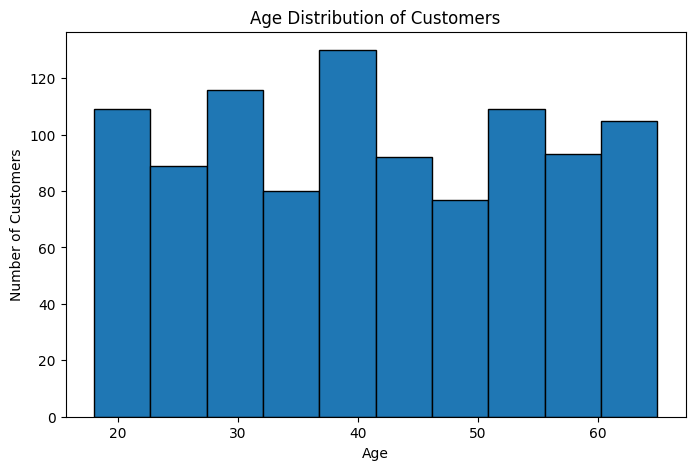

In [ ]:
# Age Distribution Histogram

plt.figure(figsize=(8, 5))

plt.hist(df["Age"], bins=10, edgecolor="black")

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

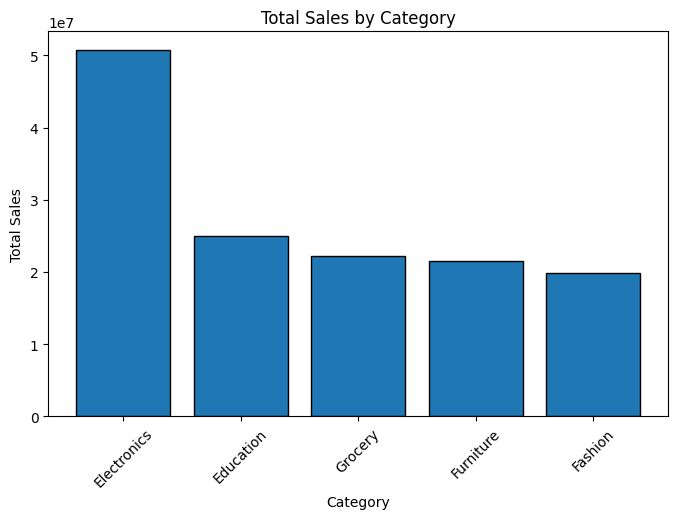

In [ ]:
# Sales by Category

category_sales = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values, edgecolor="black")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

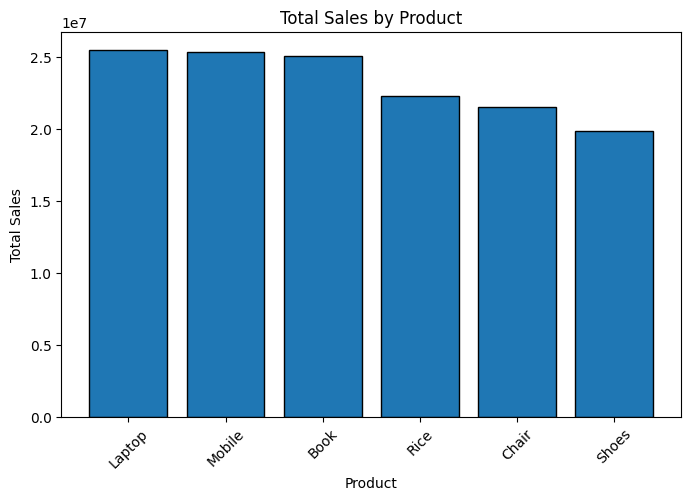

In [ ]:
# Sales by Product

product_sales = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))

plt.bar(product_sales.index, product_sales.values, edgecolor="black")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

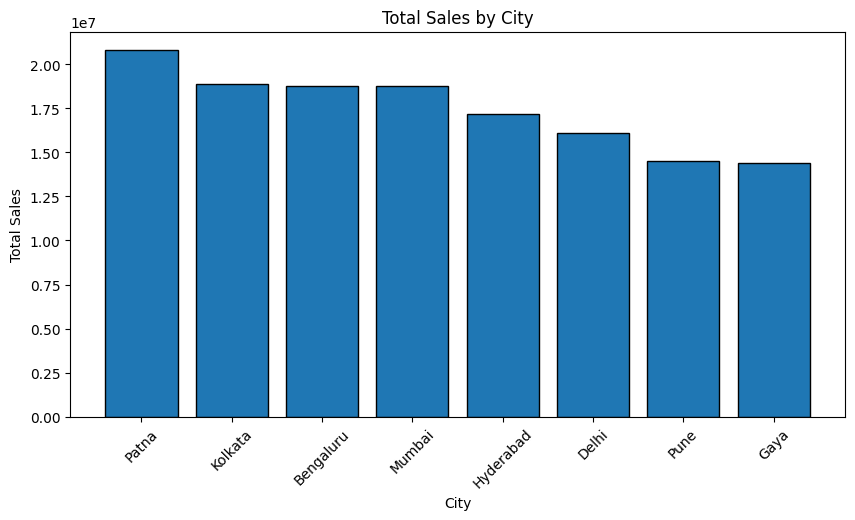

In [ ]:
# Sales by City

city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

plt.bar(city_sales.index, city_sales.values, edgecolor="black")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

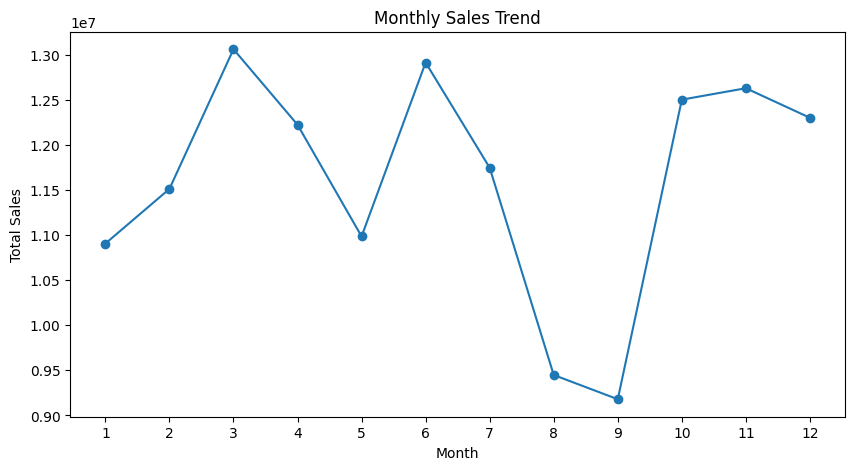

In [ ]:
# Monthly Sales Trend

monthly_sales = df.groupby("Order_Month")["Total_Sales"].sum()

plt.figure(figsize=(10, 5))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))

plt.show()

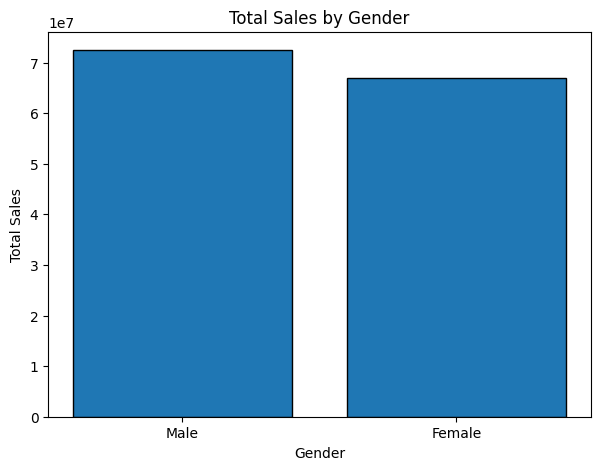

In [ ]:
# Sales by Gender

gender_sales = df.groupby("Gender")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))

plt.bar(gender_sales.index, gender_sales.values, edgecolor="black")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
# Top 5 Customers by Total Spending

top_customers = (
    df.groupby(["Customer_ID", "Customer_Name"])["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("Top 5 Customers by Total Spending:")
print(top_customers)

Top 5 Customers by Total Spending:
Customer_ID  Customer_Name
CUST2062     Customer_254     493677.5
CUST4706     Customer_200     492174.1
CUST1711     Customer_36      490866.4
CUST4869     Customer_392     485667.8
CUST7416     Customer_191     482551.9
Name: Total_Sales, dtype: float64


In [ ]:
# SQL Setup

import sqlite3

# Create SQLite database
conn = sqlite3.connect("apexplanet_task2.db")

# Load the cleaned dataset into SQL
df.to_sql("sales", conn, if_exists="replace", index=False)

print("SQL database created successfully!")
print("Table name: sales")

SQL database created successfully!
Table name: sales


In [ ]:
# SQL Business Question 1
# What is the total revenue generated?

query = """
SELECT SUM(Total_Sales) AS Total_Revenue
FROM sales;
"""

result = pd.read_sql_query(query, conn)

print(result)

   Total_Revenue
0   1.393994e+08


In [ ]:
# SQL Business Question 2
# Which product generated the highest total revenue?

query = """
SELECT Product,
       SUM(Total_Sales) AS Total_Revenue
FROM sales
GROUP BY Product
ORDER BY Total_Revenue DESC
LIMIT 1;
"""

result = pd.read_sql_query(query, conn)

print(result)

  Product  Total_Revenue
0  Laptop    25443008.51


In [ ]:
# SQL Business Question 3
# Which category generated the highest total sales?

query = """
SELECT Category,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
LIMIT 1;
"""

result = pd.read_sql_query(query, conn)

print(result)

      Category  Total_Sales
0  Electronics   50778581.7


In [ ]:
# SQL Business Question 4
# Which city generated the highest total revenue?

query = """
SELECT City,
       SUM(Total_Sales) AS Total_Revenue
FROM sales
GROUP BY City
ORDER BY Total_Revenue DESC
LIMIT 1;
"""

result = pd.read_sql_query(query, conn)

print(result)

    City  Total_Revenue
0  Patna    20826584.43


In [ ]:
# SQL Business Question 5
# What is the monthly sales trend?

query = """
SELECT Order_Month,
       SUM(Total_Sales) AS Monthly_Sales
FROM sales
GROUP BY Order_Month
ORDER BY Order_Month;
"""

result = pd.read_sql_query(query, conn)

print(result)

    Order_Month  Monthly_Sales
0             1    10905580.72
1             2    11511181.46
2             3    13059899.94
3             4    12222700.17
4             5    10984689.25
5             6    12912332.64
6             7    11746226.80
7             8     9448471.22
8             9     9179896.29
9            10    12500936.50
10           11    12627620.22
11           12    12299904.44


In [ ]:
# SQL Business Question 6
# Which gender contributes more to total sales?

query = """
SELECT Gender,
       SUM(Total_Sales) AS Total_Sales
FROM sales
GROUP BY Gender
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)

print(result)

   Gender  Total_Sales
0    Male  72463550.63
1  Female  66935889.02


In [ ]:
# SQL Business Question 7
# Who are the top 5 customers by total spending?

query = """
SELECT Customer_ID,
       Customer_Name,
       SUM(Total_Sales) AS Total_Spending
FROM sales
GROUP BY Customer_ID, Customer_Name
ORDER BY Total_Spending DESC
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)

print(result)

  Customer_ID Customer_Name  Total_Spending
0    CUST2062  Customer_254        493677.5
1    CUST4706  Customer_200        492174.1
2    CUST1711   Customer_36        490866.4
3    CUST4869  Customer_392        485667.8
4    CUST7416  Customer_191        482551.9


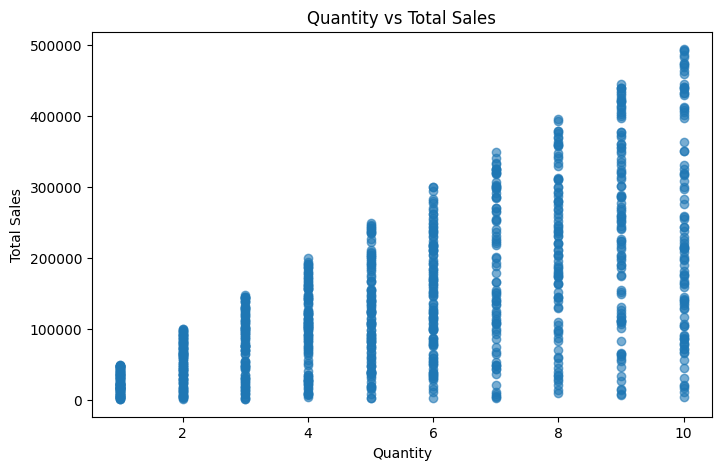

In [ ]:
# Scatter Plot: Quantity vs Total Sales

plt.figure(figsize=(8, 5))

plt.scatter(df["Quantity"], df["Total_Sales"], alpha=0.6)

plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")

plt.show()

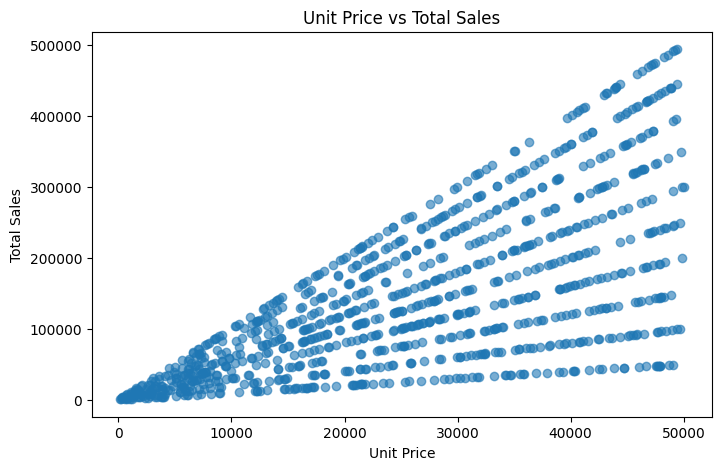

In [ ]:
# Scatter Plot: Unit Price vs Total Sales

plt.figure(figsize=(8, 5))

plt.scatter(df["Unit_Price"], df["Total_Sales"], alpha=0.6)

plt.title("Unit Price vs Total Sales")
plt.xlabel("Unit Price")
plt.ylabel("Total Sales")

plt.show()

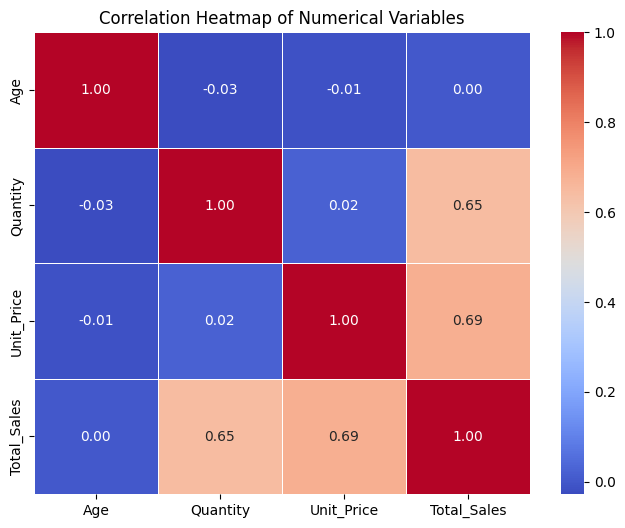

In [ ]:
# Correlation Heatmap

correlation = df[["Age", "Quantity", "Unit_Price", "Total_Sales"]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

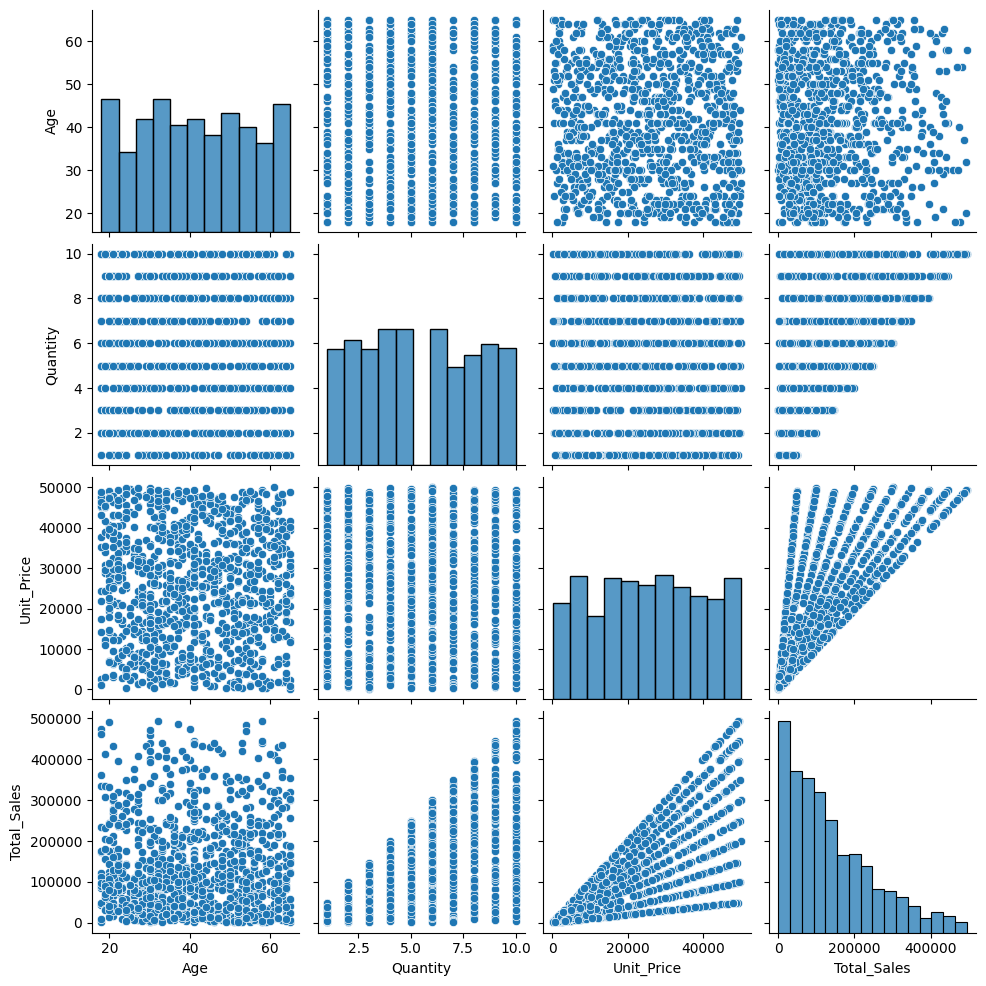

In [ ]:
# Pair Plot of Numerical Variables

sns.pairplot(
    df[["Age", "Quantity", "Unit_Price", "Total_Sales"]]
)

plt.show()

In [ ]:
# Display correlation values

correlation = df[["Age", "Quantity", "Unit_Price", "Total_Sales"]].corr()

print("Correlation Matrix:")
print(correlation.round(2))

Correlation Matrix:
              Age  Quantity  Unit_Price  Total_Sales
Age          1.00     -0.03       -0.01         0.00
Quantity    -0.03      1.00        0.02         0.65
Unit_Price  -0.01      0.02        1.00         0.69
Total_Sales  0.00      0.65        0.69         1.00
